In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from RNNs_utils import *
from RNNs_model import *

import warnings
warnings.filterwarnings("ignore")

monthly = pd.read_csv('../Datasets/paper_data/Boulder_Monthly.csv')
monthly.drop(columns={'Unnamed: 0','Date', 'Month_num', 'Year'}, inplace=True)
monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Energy__kWh_   55 non-null     float64
 1   Month          55 non-null     object 
 2   Minimum T      55 non-null     float64
 3   Maximum T      55 non-null     float64
 4   Snow           55 non-null     float64
 5   Precipitation  55 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.7+ KB


In [2]:
monthly.head()

,Energy__kWh_,Month,Minimum T,Maximum T,Snow,Precipitation
0,6.489679,January,24.653061,53.209184,2.060510,0.191796
1,7.982793,February,19.506803,45.901361,12.316063,0.698457
2,7.275274,March,29.423729,58.858757,4.397285,1.650282
3,7.506191,April,33.666667,65.052874,5.135063,1.099154
4,7.422334,May,45.959930,74.139373,0.000000,3.438589


In [3]:
monthly.columns

Index(['Energy__kWh_', 'Month', 'Minimum T', 'Maximum T', 'Snow',
       'Precipitation'],
      dtype='object')

## **Preprocessing**

In [4]:
train_monthly, val_monthly, test_monthly = split_dataset(monthly, train_ratio=0.7, val_ratio=0.2)

Training split ratio:   0.691
Validation split ratio: 0.2
Testing split ratio:    0.109

Shapes of the datasets:
(38, 6) (11, 6) (6, 6)


    One Hot Encode

In [5]:
# One-hot encode 'Month' column for train_monthly and drop 'Month' column after one-hot encoding
train_monthly = one_hot_months(train_monthly)
train_monthly.drop(columns=['Month'], inplace=True)

# One-hot encode 'Month' column for val_monthly and drop 'Month' column after one-hot encoding
val_monthly = one_hot_months(val_monthly)
val_monthly.drop(columns=['Month'], inplace=True)

# One-hot encode 'Month' column for test_monthly and drop 'Month' column after one-hot encoding
test_monthly = one_hot_months(test_monthly)
test_monthly.drop(columns=['Month'], inplace=True)

In [6]:
train_monthly.columns

Index(['Energy__kWh_', 'Minimum T', 'Maximum T', 'Snow', 'Precipitation',
       'January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype='object')

    Create sequences for the RNNs model

In [7]:
def create_sequences(df, sequence_length, target_column, step):
    sequences = []
    targets = []

    # Generate sequences and targets/labels
    for i in range(0, len(df) - sequence_length, step):
        sequence = df.drop(columns=[target_column]).iloc[i: i + sequence_length]  # Drop target column
        target = df.iloc[i + sequence_length][target_column]
        sequences.append(sequence)
        targets.append(target)

    sequences = np.array(sequences)
    targets = np.array(targets)
    print(f'Dataset split into sequences:')
    print(f'Sequences shape: {sequences.shape}')
    print(f'Targets shape: {targets.shape}\n')

    return sequences, targets

In [8]:
# Define the time window size
sequence_length = 4

# Create sequences for training data
X_train, Y_train = create_sequences(train_monthly, sequence_length, 'Energy__kWh_', step=1)
# Create sequences for validation data
X_val, Y_val = create_sequences(val_monthly, sequence_length, 'Energy__kWh_', step=1)
# Create sequences for test data
X_test, Y_test = create_sequences(test_monthly, sequence_length, 'Energy__kWh_', step=1)

Dataset split into sequences:
Sequences shape: (34, 4, 16)
Targets shape: (34,)

Dataset split into sequences:
Sequences shape: (7, 4, 16)
Targets shape: (7,)

Dataset split into sequences:
Sequences shape: (2, 4, 16)
Targets shape: (2,)



**Scalling the Numerical columns**

    Scaling the X_train and Y_train

In [9]:
# We scale also with MinMaxScaler this input columns ['Energy__kWh_', 'Maximum T', 'Minimum T', 'Precipitation', 'Snow']
numerical_D = len(['Energy__kWh_', 'Maximum T', 'Minimum T', 'Precipitation', 'Snow'])

# ----------------------
#    SCALE THE X_train
# ----------------------

# Initialize the input scaler
inputs_scaler = MinMaxScaler()
# Extract the first 5 columns from X_train
X_train_subset = X_train[:, :, :numerical_D]
# Reshape the subset to 2D array
X_train_subset_2d = X_train_subset.reshape(-1, numerical_D)
# Fit the scaler on the subset and transform it. Also reshape the scaled subset back to the original shape
x_scaler = inputs_scaler.fit_transform(X_train_subset_2d).reshape(X_train.shape[0], X_train.shape[1], numerical_D)
# Combine the scaled subset with the remaining columns of X_train
X_train_scaled = np.concatenate([x_scaler, X_train[:, :, numerical_D:]], axis=-1)

# ----------------------
#    SCALE THE Y_train
# ----------------------

# Initialize the output scaler
output_scaler = MinMaxScaler()
# Reshape the subset to 2D array
Y_train_reshaped = Y_train.reshape(-1,1)
Y_train_scaled = output_scaler.fit_transform(Y_train_reshaped)

    Scaling the X_val, X_test and Y_val, Y_test accord to X_train MinMaxScaler

In [10]:
def scale_data_with_fitted_scaler(inputs_scaler, output_scaler, X, Y, numerical_D):
    # ----------------------
    #    SCALE THE X_array with the fitted scaler of X_train
    # ----------------------
    # Extract the first 5 columns from X
    X_subset = X[:, :, :numerical_D].reshape(-1, numerical_D)
    # Scaling 
    X_scaled_subset = inputs_scaler.transform(X_subset).reshape(X.shape[0], X.shape[1], numerical_D)
    # Combine the scaled subset with the remaining columns of X
    X_scaled = np.concatenate([X_scaled_subset, X[:, :, numerical_D:]], axis=-1)

    # ----------------------
    #    SCALE THE Y_array with the fitted scaler of X_train
    # ----------------------

    # Reshape the subset of Y to 2D array
    Y_reshaped = Y.reshape(-1,1)
    # Use the previously fitted scaler to transform the Y_reshaped
    Y_scaled = output_scaler.transform(Y_reshaped)

    return X_scaled, Y_scaled

X_val_scaled, Y_val_scaled = scale_data_with_fitted_scaler(inputs_scaler, output_scaler, X_val, Y_val, numerical_D)
X_test_scaled, Y_test_scaled = scale_data_with_fitted_scaler(inputs_scaler, output_scaler, X_test, Y_test, numerical_D)

print('Train Dataset:')
print("scaled X_train shape:", X_train_scaled.shape)
print("scaled Y_train shape:", Y_train_scaled.shape)

print('\nValidation Dataset:')
print("scaled X_val shape:", X_val_scaled.shape)
print("scaled Y_val shape:", Y_val_scaled.shape)

print('\nTest Dataset:')
print("scaled X_test shape:", X_test_scaled.shape)
print("scaled Y_test shape:", Y_test_scaled.shape)

Train Dataset:
scaled X_train shape: (34, 4, 16)
scaled Y_train shape: (34, 1)

Validation Dataset:
scaled X_val shape: (7, 4, 16)
scaled Y_val shape: (7, 1)

Test Dataset:
scaled X_test shape: (2, 4, 16)
scaled Y_test shape: (2, 1)


In [11]:
X_train_scaled.max(), X_val_scaled.max(), X_test_scaled.max()

(1.0, 1.0, 1.0)

In [12]:
X_train_scaled.min(), X_val_scaled.min(), X_test_scaled.min()

(0.0, 0.0, -0.007348983012314569)

    Create the RNNs Models

In [46]:
# Define the input shape for the models ||  input_shape = (sequence_length, num_features)
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])

# Define common parameters
simple_rnn_num_layers, lstm_num_layers, bi_lstm_num_layers, gru_num_layers = 6, 3, 3, 3
simple_rnn_num_units, lstm_num_units, bi_lstm_num_units, gru_num_units = 128, 64, 64, 64
recurrent_activation_function = 'relu'
# Define the default regularation l2=0.01  ||  If we want we can train the model without regularations. (regularization = 0)
kernel_regularization = 0.01
recurrent_regularization = 0
bias_regularization = 0
dropout_rate = 0
recurrent_dropout_rate = 0.1

In [47]:
# -------------------
# Build the Models
# -------------------

# Create Simple RNN model
simple_rnn = RnnModel('SimpleRNN', input_shape, simple_rnn_num_layers, simple_rnn_num_units, recurrent_activation_function,
                      recurrent_regularization, kernel_regularization, bias_regularization,
                      dropout_rate, recurrent_dropout_rate)

# Create LSTM model
lstm = RnnModel('LSTM', input_shape, lstm_num_layers, lstm_num_units, recurrent_activation_function,
                recurrent_regularization, kernel_regularization, bias_regularization,
                dropout_rate, recurrent_dropout_rate)

# Create GRU model
gru = RnnModel('GRU', input_shape, gru_num_layers, gru_num_units, recurrent_activation_function,
               recurrent_regularization, kernel_regularization, bias_regularization,
               dropout_rate, recurrent_dropout_rate)

# Create Bi-LSTM model
bi_lstm = RnnModel('Bi-LSTM', input_shape, bi_lstm_num_layers, bi_lstm_num_units, recurrent_activation_function,
                   recurrent_regularization, kernel_regularization, bias_regularization,
                   dropout_rate, recurrent_dropout_rate)


print("Models created successfully.")

Models created successfully.


In [48]:
# Print summaries of the configurations
print("LSTM Summary:")
lstm.summary()
print()

print("Simple RNN Summary:")
simple_rnn.summary()
print()

print("Bi-LSTM Summary:")
bi_lstm.summary()
print()

print("GRU Summary:")
gru.summary()

LSTM Summary:
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 4, 64)             20736     
                                                                 
 lstm_7 (LSTM)               (None, 4, 64)             33024     
                                                                 
 lstm_8 (LSTM)               (None, 64)                33024     
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 86,849
Trainable params: 86,849
Non-trainable params: 0
_________________________________________________________________

Simple RNN Summary:
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Para

    Compile the models

In [49]:
# Define the learning rate for Adam optimizer
learning_rate = 0.001

# Define a dictionary to map model names to their corresponding model objects
rnn_models = {
    'simple_rnn': simple_rnn,
    'lstm': lstm,
    'gru': gru,
    'bi_lstm': bi_lstm
}

# Compile each RNN model
for model_name, model in rnn_models.items():
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = learning_rate), loss='mse', metrics=['mae', root_mean_squared_error])

    Train the Models

In [50]:
def train_rnn_model(model, X_train, Y_train, X_val, Y_val, epochs, batch_size, model_name):
    """
    Train an RNN model and save it.
    
    Args:
    - model: The RNN model to train.
    - X_train: Input data for training.
    - Y_train: Target data for training.
    - X_val: Input data for validation.
    - Y_val: Target data for validation.
    - epochs: Number of epochs for training.
    - batch_size: Batch size for training.
    - model_name: The name of the model to save.
    
    Returns:
    - History object containing training/validation loss and metric values.
    """
    history = model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, Y_val)
    )
    
    # Save the trained model
    model.save(f"{model_name}.h5")  # Save as HDF5 file
    print(f"Model saved as {model_name}.h5")
    
    return history

In [51]:
# Define the parameters for training
lstm_epochs = 100
simple_rnn_epochs, bi_lstm_epochs, gru_epochs = 200, 200, 200
batch_size = 1

# Train each RNN model and save them
print('-----------------\nLSTM Training\n-----------------\n')
lstm_history = train_rnn_model(lstm, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, lstm_epochs, batch_size, "montlhy_lstm_model")

print('\n-----------------\nSimpleRNN / Vanilla RNN Training\n-----------------\n')
simple_rnn_history = train_rnn_model(simple_rnn, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, simple_rnn_epochs, batch_size, "montlhy_simple_rnn_model")

print('\n-----------------\nBi-LSTM Training\n-----------------\n')
bi_lstm_history = train_rnn_model(bi_lstm, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, bi_lstm_epochs, batch_size, "montlhy_bi_lstm_model")

print('\n-----------------\nGRU Training\n-----------------\n')
gru_history = train_rnn_model(gru, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, gru_epochs, batch_size, "montlhy_gru_model")

-----------------
LSTM Training
-----------------

Epoch 1/100
34/34 [==============================] - 11s 71ms/step - loss: 1.8762 - mae: 0.4152 - root_mean_squared_error: 0.4152 - val_loss: 1.3003 - val_mae: 0.3913 - val_root_mean_squared_error: 0.3913
Epoch 2/100
34/34 [==============================] - 0s 12ms/step - loss: 0.8015 - mae: 0.1943 - root_mean_squared_error: 0.1943 - val_loss: 0.6113 - val_mae: 0.2814 - val_root_mean_squared_error: 0.2814
Epoch 3/100
34/34 [==============================] - 1s 18ms/step - loss: 0.3727 - mae: 0.1960 - root_mean_squared_error: 0.1960 - val_loss: 0.3237 - val_mae: 0.2556 - val_root_mean_squared_error: 0.2556
Epoch 4/100
34/34 [==============================] - 0s 13ms/step - loss: 0.1870 - mae: 0.1918 - root_mean_squared_error: 0.1918 - val_loss: 0.2132 - val_mae: 0.2550 - val_root_mean_squared_error: 0.2550
Epoch 5/100
34/34 [==============================] - 0s 12ms/step - loss: 0.1158 - mae: 0.1957 - root_mean_squared_error: 0.1957 - v

    Evaluate the Models

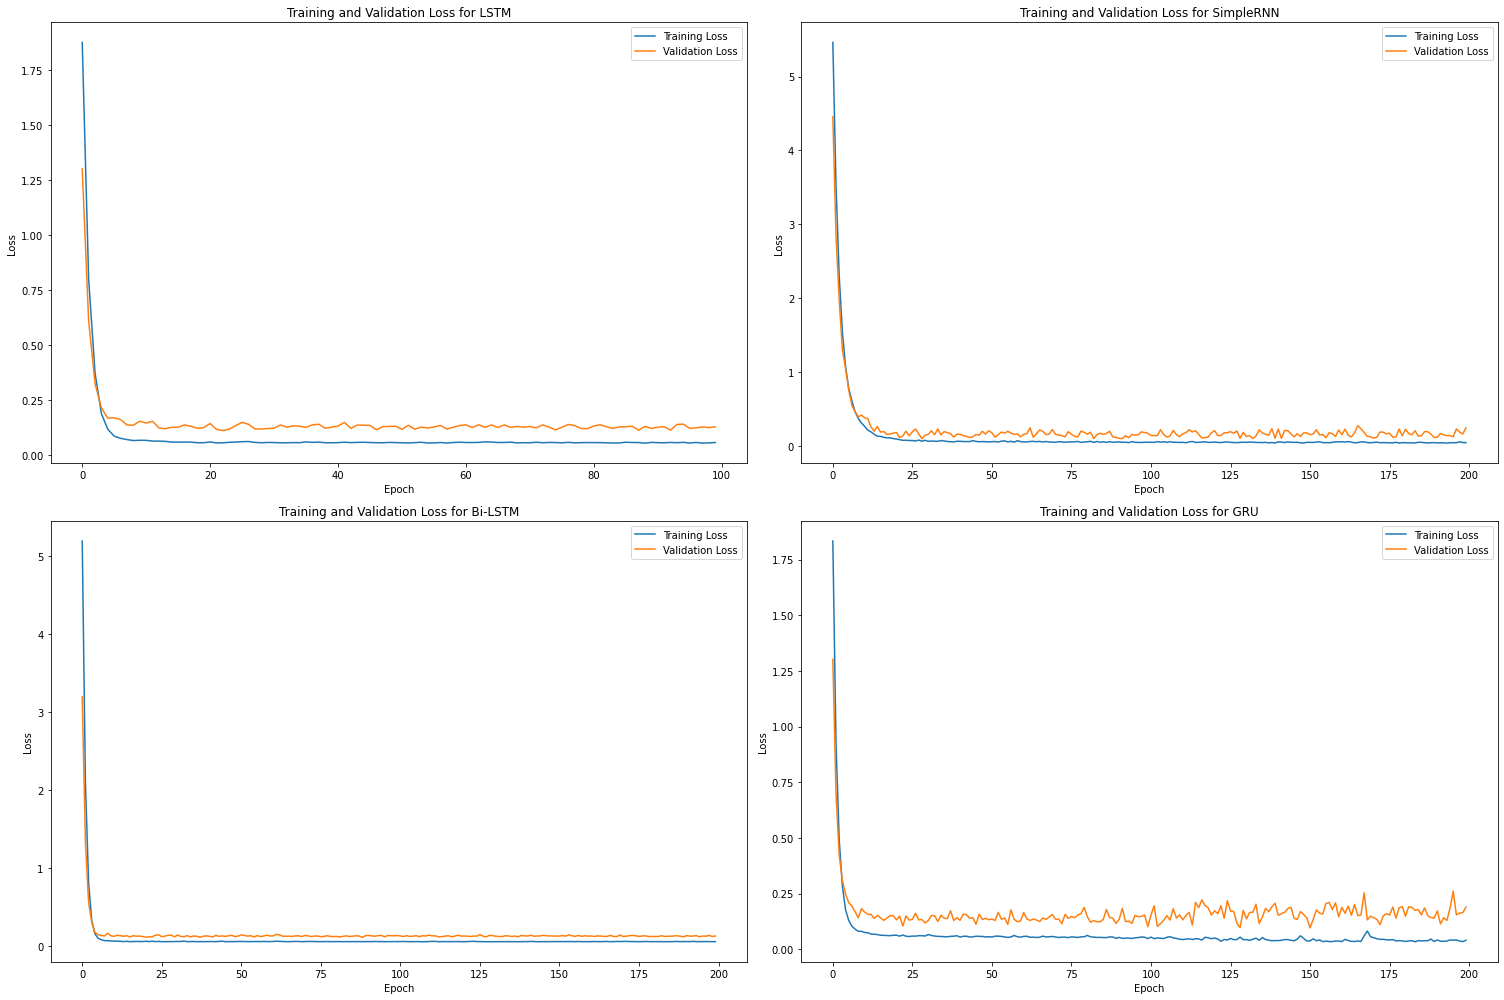

In [52]:
def plot_loss(history, model_name, ax):
    ax.plot(history.history['loss'], label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training and Validation Loss for ' + model_name)
    ax.legend()

    

fig, axes = plt.subplots(2, 2, figsize=(21, 14))
axes = axes.flatten()
histories = []
model_names = ['LSTM', 'SimpleRNN', 'Bi-LSTM', 'GRU']
histories.extend([lstm_history, simple_rnn_history, bi_lstm_history, gru_history])
for i, (history, model_name) in enumerate(zip(histories, model_names)):
    plot_loss(history, model_name, axes[i])
# Hide empty subplots
for i in range(len(histories), len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [13]:
# from tensorflow.keras.models import load_model

# # Load each model, passing the custom RMSE function
# lstm = load_model('../model_saves/paper_method/montlhy_lstm_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})
# simple_rnn = load_model('../model_saves/paper_method/montlhy_simple_rnn_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})
# bi_lstm = load_model('../model_saves/paper_method/montlhy_bi_lstm_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})
# gru = load_model('../model_saves/paper_method/montlhy_gru_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})

In [14]:
##     Evaluate the Models in scaled data
def evaluate_model(model, model_name, X_train, Y_train, X_val, Y_val, X_test, Y_test):
    train_eval = model.evaluate(X_train, Y_train, verbose=0)
    val_eval = model.evaluate(X_val, Y_val, verbose=0)
    test_eval = model.evaluate(X_test, Y_test, verbose=0)
    print(f'\nEvaluation metrics for {model_name} model:\n-------------------')
    print('Training Data - Loss: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}'.format(train_eval[0], train_eval[1], train_eval[2]))
    print('Validation Data - Loss: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}'.format(val_eval[0], val_eval[1], val_eval[2]))
    print('Test Data - Loss: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}'.format(test_eval[0], test_eval[1], test_eval[2]),'\n')
    # print(model.metrics_names)

##     Evaluate the Models in scaled data
evaluate_model(lstm, 'LSTM',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)
evaluate_model(simple_rnn, 'RNN',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)
evaluate_model(bi_lstm, 'Bi-LSTM',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)
evaluate_model(gru, 'GRU',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)


Evaluation metrics for LSTM model:
-------------------
Training Data - Loss: 0.0534, MAE: 0.1838, RMSE: 0.1723
Validation Data - Loss: 0.1310, MAE: 0.2543, RMSE: 0.3620
Test Data - Loss: 0.0616, MAE: 0.2311, RMSE: 0.2481 


Evaluation metrics for RNN model:
-------------------
Training Data - Loss: 0.0532, MAE: 0.1798, RMSE: 0.1669
Validation Data - Loss: 0.1246, MAE: 0.2485, RMSE: 0.3530
Test Data - Loss: 0.0555, MAE: 0.2176, RMSE: 0.2356 


Evaluation metrics for Bi-LSTM model:
-------------------
Training Data - Loss: 0.0532, MAE: 0.1784, RMSE: 0.1651
Validation Data - Loss: 0.1224, MAE: 0.2464, RMSE: 0.3499
Test Data - Loss: 0.0534, MAE: 0.2127, RMSE: 0.2311 


Evaluation metrics for GRU model:
-------------------
Training Data - Loss: 0.0309, MAE: 0.1117, RMSE: 0.1075
Validation Data - Loss: 0.1419, MAE: 0.2954, RMSE: 0.3639
Test Data - Loss: 0.0998, MAE: 0.2672, RMSE: 0.3006 



In [15]:
evaluate_predictions_model(lstm, 'LSTM', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)
evaluate_predictions_model(simple_rnn, 'RNN', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)
evaluate_predictions_model(bi_lstm, 'Bi-LSTM', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)
evaluate_predictions_model(gru, 'GRU', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)

1/1 [==============================] - 0s 41ms/step


Evaluation metrics for LSTM model:
-------------------
Train RMSE: 0.75 // 0.23105776583710902
Train MAE: 0.60 // 0.18379795416934813
-------------------
Validation RMSE: 1.17 // 0.36195604599303793
Validation MAE: 0.83 // 0.25427055278647714
-------------------
Test RMSE: 0.81 // 0.2481390096057679
Test MAE: 0.75 // 0.23114659731612752


1/1 [==============================] - 0s 73ms/step


Evaluation metrics for RNN model:
-------------------
Train RMSE: 0.75 // 0.2306868138783507
Train MAE: 0.58 // 0.1798155136556251
-------------------
Validation RMSE: 1.15 // 0.35301210616001805
Validation MAE: 0.81 // 0.24846756803790931
-------------------
Test RMSE: 0.76 // 0.23557741880245003
Test MAE: 0.71 // 0.2176062995694692


1/1 [==============================] - 0s 47ms/step


Evaluation metrics for Bi-LSTM model:
-------------------
Train RMSE: 0.75 // 0.2307475943120525
Train MAE: 0.58 // 0.1783833367571176
-------------------
Vali